In [1]:
pip install pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/Users/indrapal/untitled folder 2/customer_churn_platform/etl/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df["Churn"]


0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [6]:
categorical_features = df.select_dtypes(include=['object']).columns
print(categorical_features)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [7]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


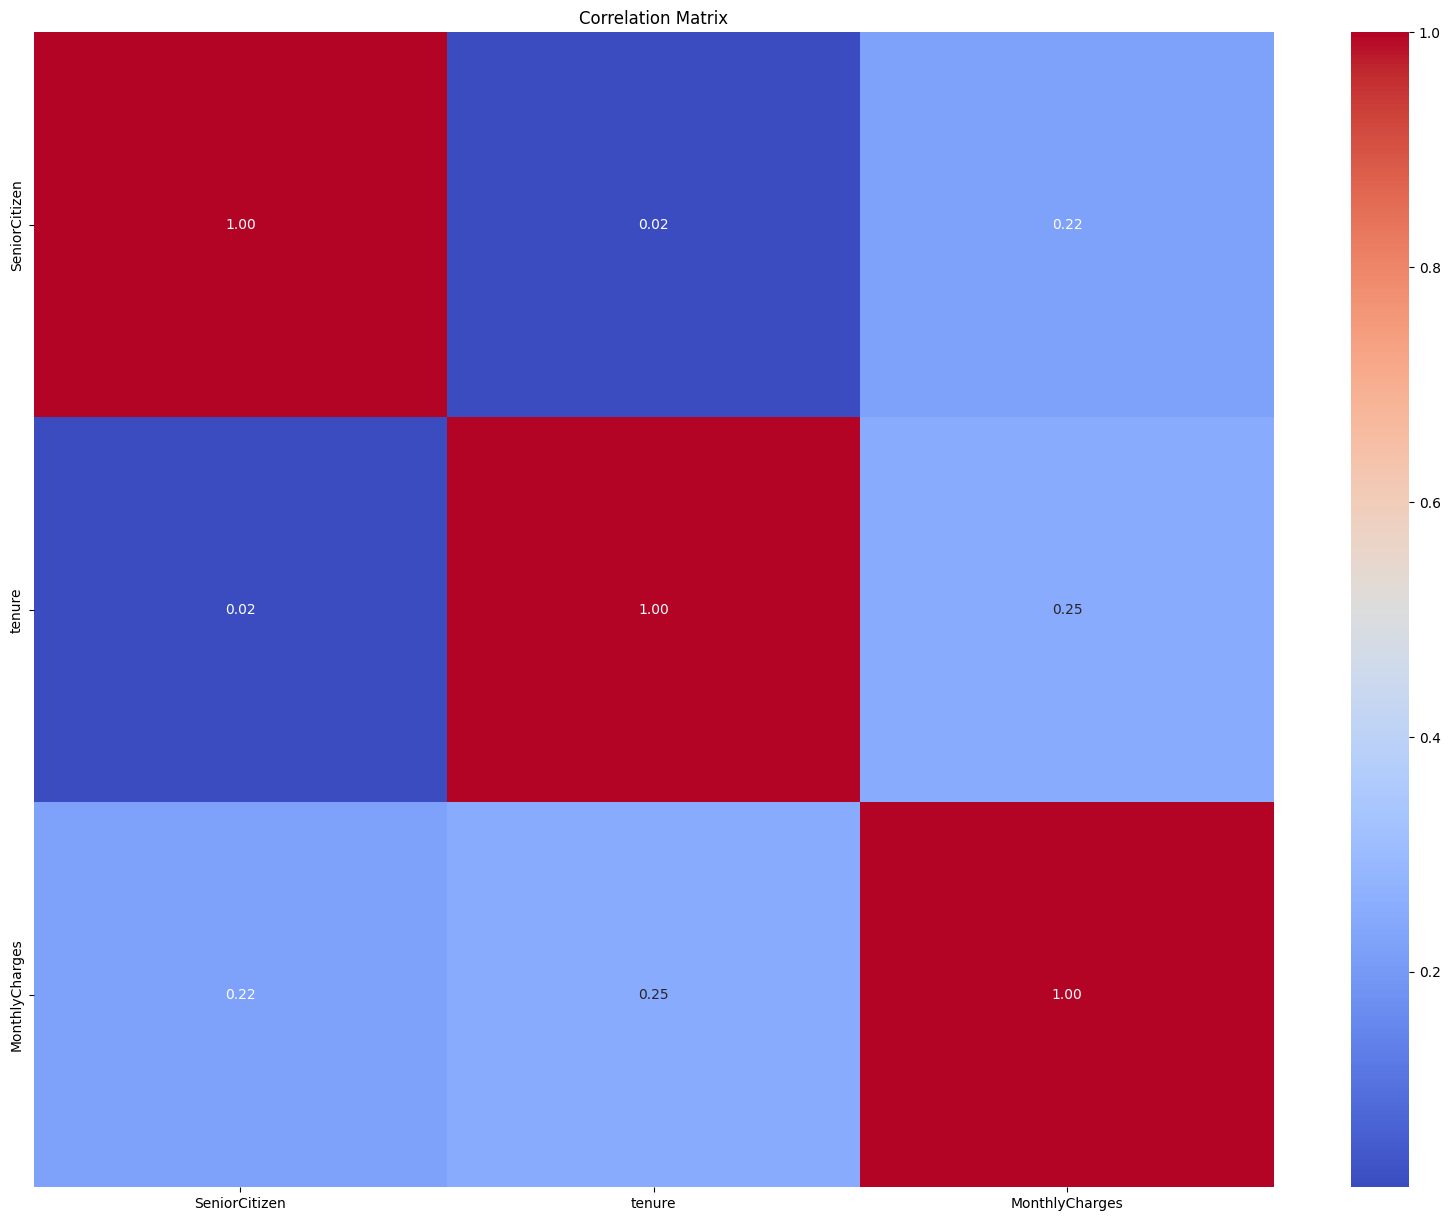

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
print(df["TotalCharges"].isnull().sum())

11


In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = (
    df["TotalCharges"]
    .fillna(df["TotalCharges"].median())
)

In [14]:
duplicates = df.duplicated().sum()

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df["Churn"] = (
    df["Churn"]
    .map({"Yes": 1, "No": 0})
)

In [17]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)

Churn
0    5174
1    1869
Name: count, dtype: int64


In [18]:
df["avg_monthly_value"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)

)
print(df["avg_monthly_value"].head())

0    14.925000
1    53.985714
2    36.050000
3    40.016304
4    50.550000
Name: avg_monthly_value, dtype: float64


In [19]:
df["charge_to_tenure_ratio"] = (
        df["MonthlyCharges"] / (df["tenure"] + 1))
print(df["charge_to_tenure_ratio"].head())

0    14.925000
1     1.627143
2    17.950000
3     0.919565
4    23.566667
Name: charge_to_tenure_ratio, dtype: float64


In [20]:
df["customer_lifetime_category"] = pd.cut(
        df["tenure"],
        bins=[0, 12, 36, 60, 100],
        labels=["New", "Growing", "Loyal", "Veteran"]
    )
print(df["customer_lifetime_category"].value_counts())


customer_lifetime_category
New        2175
Growing    1856
Loyal      1594
Veteran    1407
Name: count, dtype: int64


In [21]:
service_columns = [
        "PhoneService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

df["service_count"] = (
        df[service_columns]
        .apply(
            lambda row:
            sum(
                value == "Yes"
                for value in row
            ),
            axis=1
        )
    )
print(df["service_count"].head())

0    1
1    3
2    3
3    3
4    1
Name: service_count, dtype: int64


In [22]:
protection_columns = [
        "OnlineSecurity",
        "DeviceProtection",
        "TechSupport"
    ]

df["protection_score"] = (
        df[protection_columns]
        .apply(
            lambda row:
            sum(
                value == "Yes"
                for value in row
            ),
            axis=1
        )
    )
print(df["protection_score"])

0       0
1       2
2       1
3       3
4       0
       ..
7038    3
7039    1
7040    1
7041    0
7042    3
Name: protection_score, Length: 7043, dtype: int64


In [23]:
auto_pay_methods = [
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]

df["is_auto_pay"] = (
        df["PaymentMethod"]
        .isin(auto_pay_methods)
        .astype(int)
    )
print(df["is_auto_pay"].head())

0    0
1    0
2    0
3    1
4    0
Name: is_auto_pay, dtype: int64


In [24]:
contract_mapping = {
        "Month-to-month": 2,
        "One year": 1,
        "Two year": 0
    }

df["contract_risk"] = (
        df["Contract"]
        .map(contract_mapping)
    )
print(df["contract_risk"].head())

0    2
1    1
2    2
3    1
4    2
Name: contract_risk, dtype: int64


In [25]:
internet_mapping = {
        "Fiber optic": 2,
        "DSL": 1,
        "No": 0
    }

df["internet_dependency_score"] = (
        df["InternetService"]
        .map(internet_mapping)
    )
print(df["internet_dependency_score"].head())

0    1
1    1
2    1
3    1
4    2
Name: internet_dependency_score, dtype: int64


In [26]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [27]:
y=df["Churn"]

In [28]:
categorical_features = [
    "customer_lifetime_category",
    "Dependents"
]

In [29]:
numeric_features = [
    "service_count",
    "protection_score",
    "is_auto_pay",
    "contract_risk",
    "avg_monthly_value",
    "charge_to_tenure_ratio",
    "internet_dependency_score"
]

In [30]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

In [31]:
dependents_encoded = ohe.fit_transform(
    df[["Dependents"]]
)
print(dependents_encoded)


[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [32]:
dependents_cols = ohe.get_feature_names_out(
    ["Dependents"]
)
print(dependents_cols)

['Dependents_No' 'Dependents_Yes']


In [33]:
lifetime_encoded = ohe.fit_transform(
    df[["customer_lifetime_category"]]
)
print(lifetime_encoded)


[[0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 ...
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]


In [34]:
lifetime_cols = ohe.get_feature_names_out(
    ["customer_lifetime_category"]
)
print(lifetime_cols)

['customer_lifetime_category_Growing' 'customer_lifetime_category_Loyal'
 'customer_lifetime_category_New' 'customer_lifetime_category_Veteran'
 'customer_lifetime_category_nan']


In [35]:

dependents_df = pd.DataFrame(
    dependents_encoded,
    columns=dependents_cols
)

In [36]:
print(dependents_df)

      Dependents_No  Dependents_Yes
0               1.0             0.0
1               1.0             0.0
2               1.0             0.0
3               1.0             0.0
4               1.0             0.0
...             ...             ...
7038            0.0             1.0
7039            0.0             1.0
7040            0.0             1.0
7041            1.0             0.0
7042            1.0             0.0

[7043 rows x 2 columns]


In [37]:
lifetime_df = pd.DataFrame(
    lifetime_encoded,
    columns=lifetime_cols
)
print(lifetime_df)

      customer_lifetime_category_Growing  customer_lifetime_category_Loyal  \
0                                    0.0                               0.0   
1                                    1.0                               0.0   
2                                    0.0                               0.0   
3                                    0.0                               1.0   
4                                    0.0                               0.0   
...                                  ...                               ...   
7038                                 1.0                               0.0   
7039                                 0.0                               0.0   
7040                                 0.0                               0.0   
7041                                 0.0                               0.0   
7042                                 0.0                               0.0   

      customer_lifetime_category_New  customer_lifetime_categor

In [38]:
df = pd.concat(
    [df, dependents_df],
    axis=1
)

df.drop(
    columns=["Dependents"],
    inplace=True
)

In [39]:
df = pd.concat(
    [df, lifetime_df],
    axis=1
)

df.drop(
    columns=["customer_lifetime_category"],
    inplace=True
)

In [40]:
df

,customerID,gender,SeniorCitizen,Partner,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,is_auto_pay,contract_risk,internet_dependency_score,Dependents_No,Dependents_Yes,customer_lifetime_category_Growing,customer_lifetime_category_Loyal,customer_lifetime_category_New,customer_lifetime_category_Veteran,customer_lifetime_category_nan
0,7590-VHVEG,Female,0,Yes,1,No,No phone service,DSL,No,Yes,...,0,2,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5575-GNVDE,Male,0,No,34,Yes,No,DSL,Yes,No,...,0,1,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3668-QPYBK,Male,0,No,2,Yes,No,DSL,Yes,Yes,...,0,2,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,7795-CFOCW,Male,0,No,45,No,No phone service,DSL,Yes,No,...,1,1,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,9237-HQITU,Female,0,No,2,Yes,No,Fiber optic,No,No,...,0,2,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,24,Yes,Yes,DSL,Yes,No,...,0,1,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0
7039,2234-XADUH,Female,0,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,1,1,2,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7040,4801-JZAZL,Female,0,Yes,11,No,No phone service,DSL,Yes,No,...,0,2,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7041,8361-LTMKD,Male,1,Yes,4,Yes,Yes,Fiber optic,No,No,...,0,2,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [41]:
X = df[
    [
        "service_count",
        "protection_score",
        "is_auto_pay",
        "contract_risk",
        "avg_monthly_value",
        "charge_to_tenure_ratio",
        "internet_dependency_score",

        "Dependents_No",
        "Dependents_Yes",

        "customer_lifetime_category_New",
        "customer_lifetime_category_Growing",
        "customer_lifetime_category_Loyal",
        "customer_lifetime_category_Veteran",

        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "SeniorCitizen"
    ]
]

In [42]:
X = pd.DataFrame(X)

In [43]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [44]:
X

,service_count,protection_score,is_auto_pay,contract_risk,avg_monthly_value,charge_to_tenure_ratio,internet_dependency_score,Dependents_No,Dependents_Yes,customer_lifetime_category_New,customer_lifetime_category_Growing,customer_lifetime_category_Loyal,customer_lifetime_category_Veteran,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
0,1,0,0,2,14.925000,14.925000,1,1.0,0.0,1.0,0.0,0.0,0.0,1,29.85,29.85,0
1,3,2,0,1,53.985714,1.627143,1,1.0,0.0,0.0,1.0,0.0,0.0,34,56.95,1889.50,0
2,3,1,0,2,36.050000,17.950000,1,1.0,0.0,1.0,0.0,0.0,0.0,2,53.85,108.15,0
3,3,3,1,1,40.016304,0.919565,1,1.0,0.0,0.0,0.0,1.0,0.0,45,42.30,1840.75,0
4,1,0,0,2,50.550000,23.566667,2,1.0,0.0,1.0,0.0,0.0,0.0,2,70.70,151.65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6,3,0,1,79.620000,3.392000,1,0.0,1.0,0.0,1.0,0.0,0.0,24,84.80,1990.50,0
7039,5,1,1,1,100.861644,1.413699,2,0.0,1.0,0.0,0.0,0.0,1.0,72,103.20,7362.90,0
7040,1,1,0,2,28.870833,2.466667,1,0.0,1.0,1.0,0.0,0.0,0.0,11,29.60,346.45,0
7041,1,0,0,2,61.320000,14.880000,2,1.0,0.0,1.0,0.0,0.0,0.0,4,74.40,306.60,1


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

In [48]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [50]:
model=xgb

In [51]:
print(X.dtypes)

service_count                           int64
protection_score                        int64
is_auto_pay                             int64
contract_risk                           int64
avg_monthly_value                     float64
charge_to_tenure_ratio                float64
internet_dependency_score               int64
Dependents_No                         float64
Dependents_Yes                        float64
customer_lifetime_category_New        float64
customer_lifetime_category_Growing    float64
customer_lifetime_category_Loyal      float64
customer_lifetime_category_Veteran    float64
tenure                                  int64
MonthlyCharges                        float64
TotalCharges                          float64
SeniorCitizen                           int64
dtype: object


In [52]:
print(type(y))

<class 'pandas.core.series.Series'>


In [53]:
print(X_train.dtypes.unique())

[dtype('int64') dtype('float64')]


In [54]:
print(X_train.columns[X_train.columns.duplicated()])

Index([], dtype='object')


In [55]:
X = X.loc[:, ~X.columns.duplicated()]

In [56]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [57]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.794889992902768
Precision: 0.6460481099656358
Recall   : 0.5026737967914439
F1 Score : 0.5654135338345865
ROC AUC  : 0.833246790152161


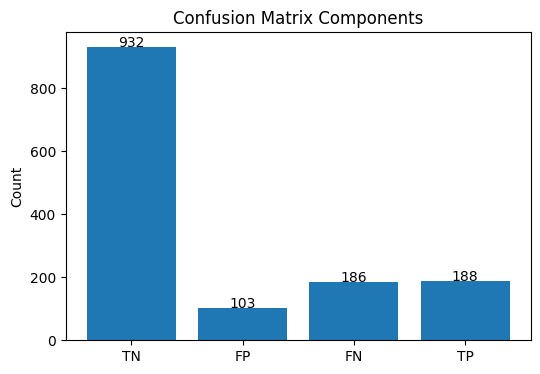

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

labels = ["TN", "FP", "FN", "TP"]
values = [tn, fp, fn, tp]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha="center")

plt.title("Confusion Matrix Components")
plt.ylabel("Count")
plt.show()

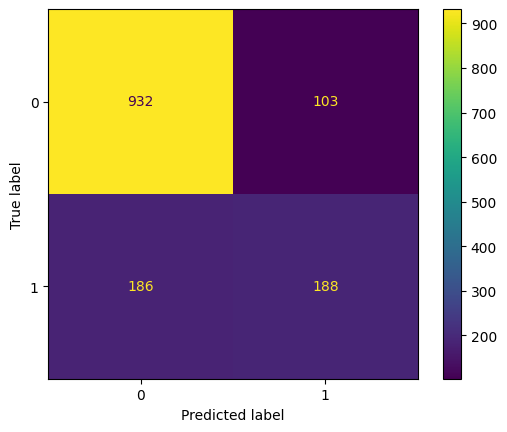

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

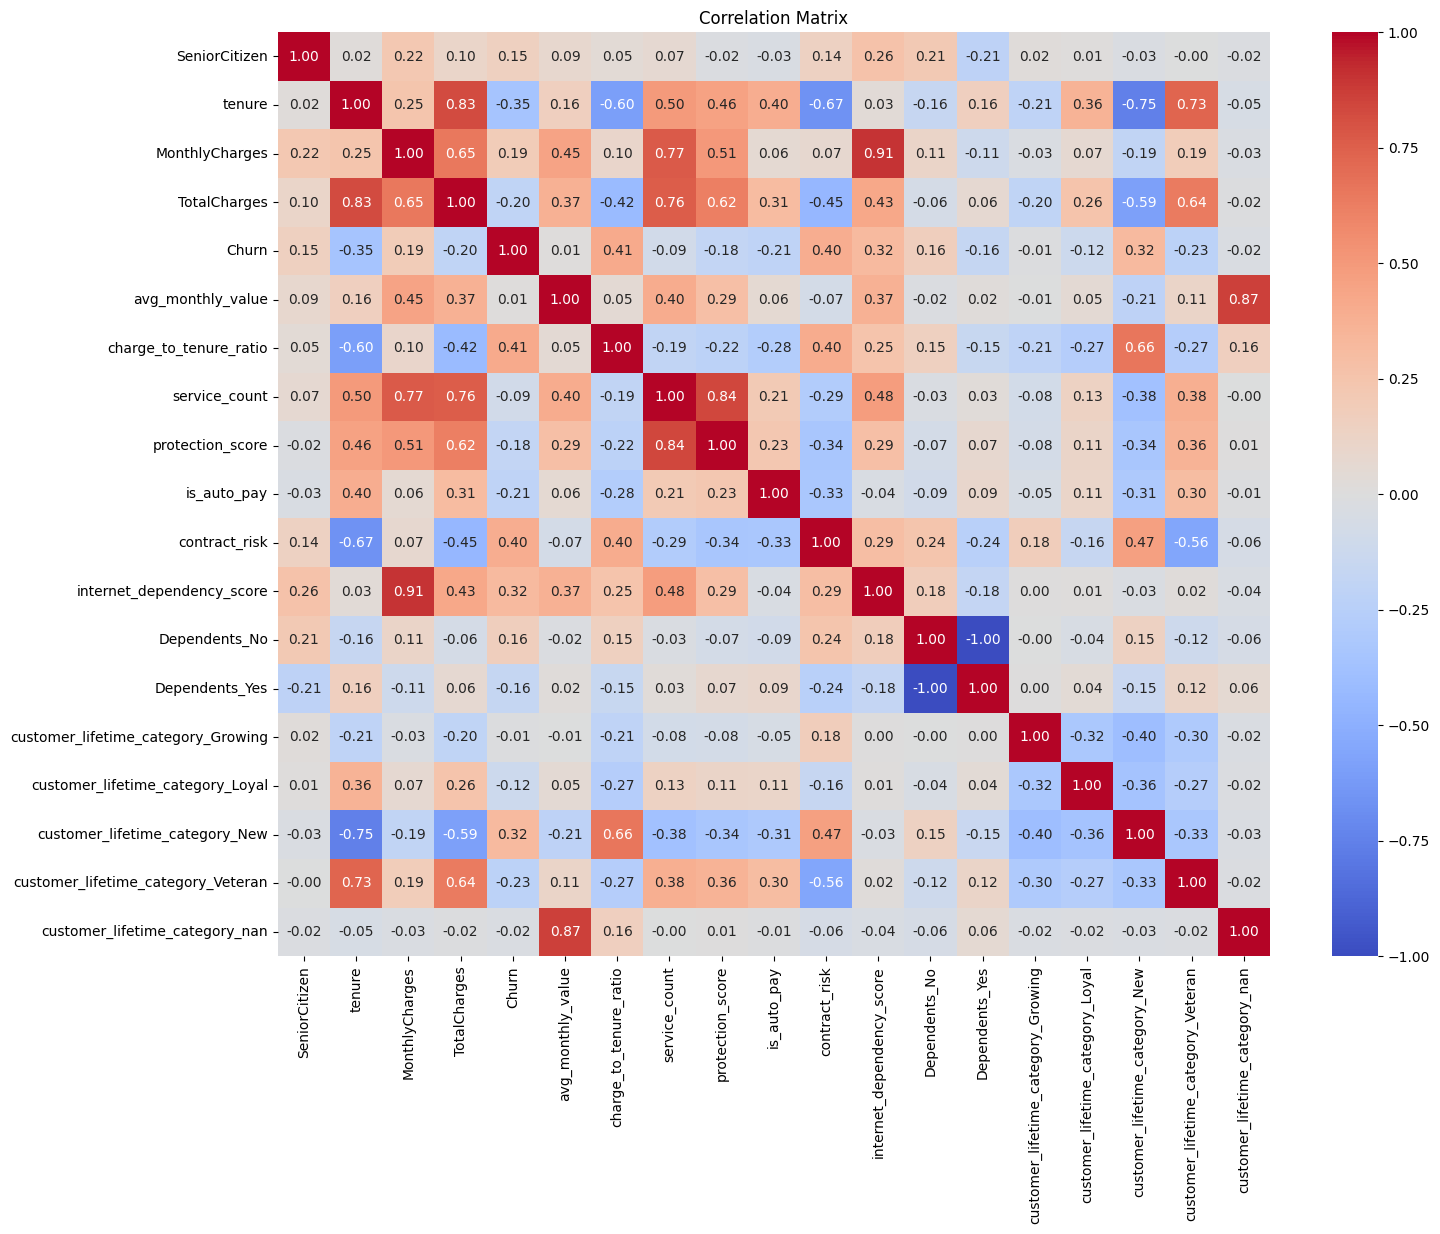

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,      # show values
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [63]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="importance",
        ascending=False
    )
)

                               feature  importance
3                        contract_risk    0.362150
6            internet_dependency_score    0.245484
5               charge_to_tenure_ratio    0.053802
13                              tenure    0.035007
1                     protection_score    0.032436
14                      MonthlyCharges    0.028343
16                       SeniorCitizen    0.027371
2                          is_auto_pay    0.026861
8                       Dependents_Yes    0.024569
15                        TotalCharges    0.024531
7                        Dependents_No    0.024120
0                        service_count    0.023427
4                    avg_monthly_value    0.023159
10  customer_lifetime_category_Growing    0.020366
11    customer_lifetime_category_Loyal    0.020348
9       customer_lifetime_category_New    0.017592
12  customer_lifetime_category_Veteran    0.010433
